In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_parquet('preprocessed.parquet')
df.head()

,pm10,pm2_5,nitrogen_dioxide,latitude,longitude,city,country,temperature_2m,wind_speed_10m,relative_humidity_2m,carbon_monoxide,aqi_category,hour,month,day_of_week
0,-0.773653,-1.078367,-0.558007,-1.12876,-0.473407,-1.505128,-1.853286,-0.771500,-0.472840,0.912249,-0.126710,Good,-1.661325,-1.597591,-0.499831
1,-0.792568,-1.078367,-0.625395,-1.12876,-0.473407,-1.505128,-1.853286,-0.878719,-0.445174,0.961327,-0.089442,Good,-1.516862,-1.597591,-0.499831
2,-0.915514,-1.078367,-0.733214,-1.12876,-0.473407,-1.505128,-1.853286,-0.890632,-0.182347,0.912249,-0.014906,Good,-1.372399,-1.597591,-0.499831
3,-0.934429,-1.027394,-0.665827,-1.12876,-0.473407,-1.505128,-1.853286,-0.842979,-0.306844,0.814095,-0.014906,Good,-1.227936,-1.597591,-0.499831
4,-0.896599,-1.001907,-0.167162,-1.12876,-0.473407,-1.505128,-1.853286,-0.831066,-0.334510,0.814095,0.003728,Good,-1.083473,-1.597591,-0.499831


In [3]:
df.columns

Index(['pm10', 'pm2_5', 'nitrogen_dioxide', 'latitude', 'longitude', 'city',
       'country', 'temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'carbon_monoxide', 'aqi_category', 'hour', 'month', 'day_of_week'],
      dtype='object')

C:\Users\omare\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.6318 - loss: 0.7764 - val_accuracy: 0.6713 - val_loss: 0.7495
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6815 - loss: 0.6709 - val_accuracy: 0.7179 - val_loss: 0.6309
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6987 - loss: 0.6282 - val_accuracy: 0.7196 - val_loss: 0.6127
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7083 - loss: 0.6005 - val_accuracy: 0.7364 - val_loss: 0.5815
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7168 - loss: 0.5822 - val_accuracy: 0.7287 - val_loss: 0.5909
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7198 - loss: 0.5689 - val_accuracy: 0.7333 - val_loss: 0.5776
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.7240 - loss: 0.5590 - val_accuracy: 0.7342 - val_loss: 0.5787
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7269 - loss: 0.5493 - val_accu

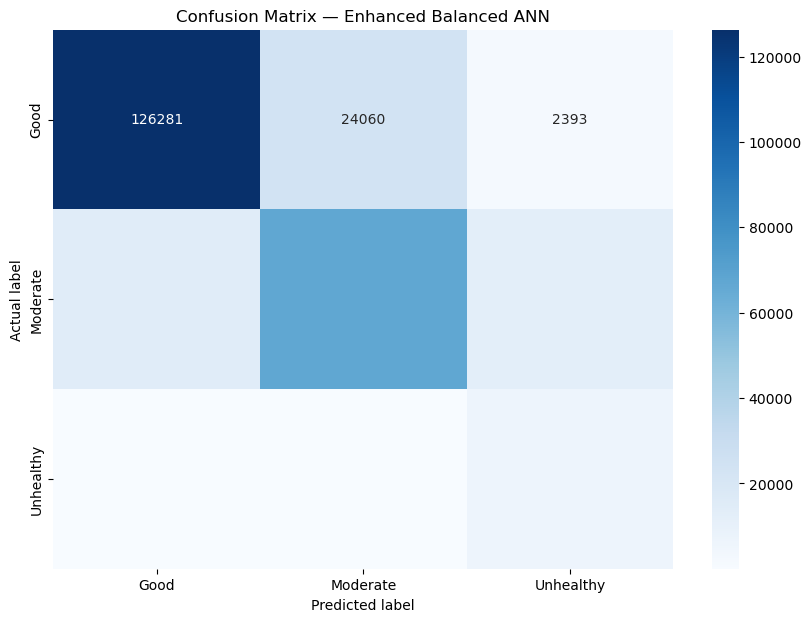

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. LOAD DATA
df = pd.read_parquet('final.parquet')

# 2. FEATURE ENGINEERING (Binning based on your new columns)
# Note: Ensure 'aqi_label' is created from your target column
if 'us_aqi' in df.columns:
    def bin_aqi(aqi):
        if aqi <= 50: return 0
        elif aqi <= 100: return 1
        else: return 2
    df['aqi_label'] = df['us_aqi'].apply(bin_aqi)
else:
    # If us_aqi is gone and you only have aqi_category as a string
    label_map = {'Good': 0, 'Moderate': 1, 'Unhealthy': 2}
    df['aqi_label'] = df['aqi_category'].map(label_map)

# 3. DEFINE FEATURES & TARGET
# We keep nitrogen_dioxide, carbon_monoxide, lat, long, and weather
# We MUST drop anything that directly reveals the answer (pm10, pm2_5, aqi_category)
drop_cols = [
    'aqi_label', 'aqi_category', 'us_aqi', 'pm10', 'pm2_5', 
    'us_aqi_pm2_5', 'us_aqi_pm10', 'time', 'index'
]

X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['aqi_label']

# 4. CATEGORICAL ENCODING & SPLITTING
X = pd.get_dummies(X, columns=['city', 'country'], drop_first=True).astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. CALCULATE CLASS WEIGHTS
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# 6. SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. ENHANCED ANN MODEL
# Added BatchNormalization to help the model learn faster with the new gas/weather features
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# 8. TRAIN
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train, 
    validation_split=0.1, 
    epochs=50, 
    batch_size=8192, # Faster processing for your large dataset
    callbacks=[early_stop], 
    class_weight=class_weight_dict,
    verbose=1
)

# 9. PREDICT & EVALUATE
probabilities = model.predict(X_test_scaled)
predictions = np.argmax(probabilities, axis=1)

print("\nANN Classification Report (Enhanced with Gas & Geo Data):")
target_names = ['Good', 'Moderate', 'Unhealthy']
print(classification_report(y_test, predictions, target_names=target_names))

# Visualization
plt.figure(figsize=(10, 7))
sns.heatmap(metrics.confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix — Enhanced Balanced ANN')
plt.show()